In [1]:
# ── IMPORTS ─────────────────────────────────────────────────────────────────────
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ta                     # indicadores técnicos
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error,
    accuracy_score, precision_score, recall_score,
)
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
# ── END IMPORTS ───────────────────────────────────────────────────────────────

In [2]:
# Definindo os códigos das ações (tickers)
tickers = ['AAPL', 'NVDA', 'MSFT', 'GOOGL']

# Baixando os dados de 2020 até o início de 2024
print("Coletando dados...")
dados_fechamento = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Exibindo as 5 primeiras linhas para conferência
print(dados_fechamento.head())

Coletando dados...


[*********************100%***********************]  4 of 4 completed

Ticker           AAPL      GOOGL        MSFT      NVDA
Date                                                  
2020-01-02  72.333878  67.873024  151.829544  5.970755
2020-01-03  71.630630  67.517960  149.938995  5.875187
2020-01-06  72.201408  69.317596  150.326569  5.899825
2020-01-07  71.861855  69.183701  148.955902  5.971252
2020-01-08  73.017838  69.676125  151.328522  5.982453


In [3]:
#  3: Extrair Estatísticas Descritivas
estatisticas = dados_fechamento.describe()

# Exibindo os resultados arredondados para facilitar a leitura
print("--- Estatísticas Descritivas ---")
print(estatisticas.round(2))

--- Estatísticas Descritivas ---
Ticker     AAPL    GOOGL     MSFT     NVDA
count   1006.00  1006.00  1006.00  1006.00
mean     137.83   106.99   253.63    21.06
std       33.33    24.91    54.69    11.75
min       54.16    52.27   128.36     4.89
25%      120.29    87.31   212.37    13.12
50%      142.68   108.99   250.39    17.57
75%      163.04   129.18   293.13    26.50
max      195.89   148.61   375.41    50.37


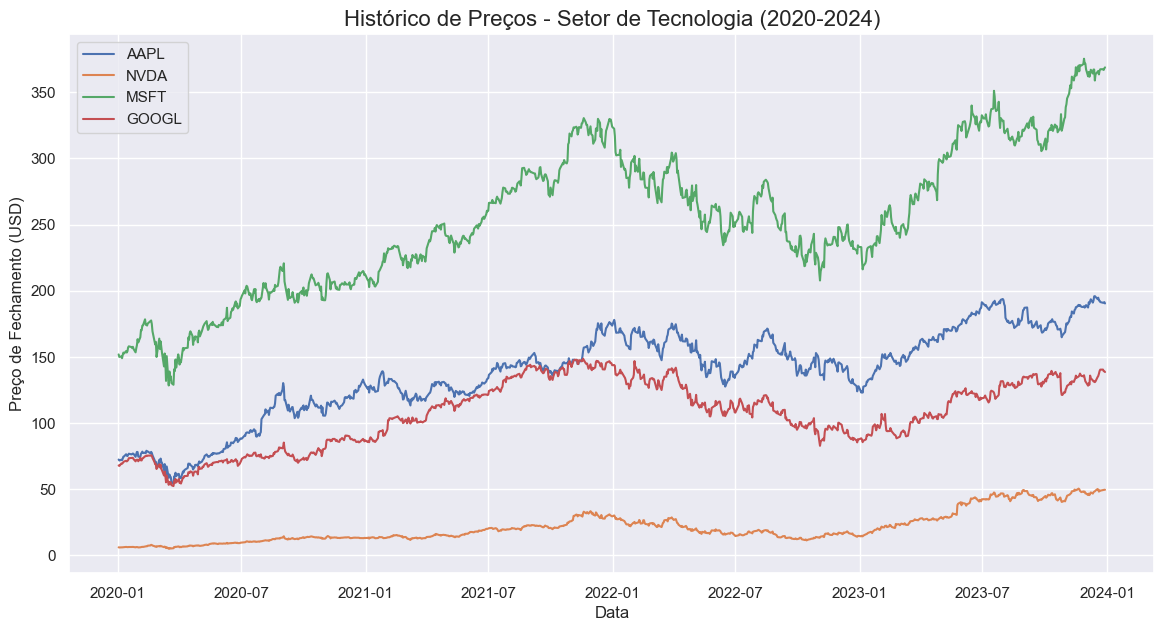

In [4]:
#  4: Visualizar a Série Temporal
plt.figure(figsize=(14, 7))

# Criando uma linha no gráfico para cada empresa
for ticker in tickers:
    plt.plot(dados_fechamento.index, dados_fechamento[ticker], label=ticker)

plt.title('Histórico de Preços - Setor de Tecnologia (2020-2024)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço de Fechamento (USD)', fontsize=12)
plt.legend()
plt.show()

## --- 2: Engenharia de Recursos (Médias Móveis e RSI) ---

In [5]:
# ==========================================
#  1: CALCULANDO AS MÉDIAS MÓVEIS
# ==========================================

print("Calculando Médias Móveis (Janela de 20 dias)...")

# 1. Calculando a SMA (Média Móvel Simples)
# A função 'rolling(window=20)' cria a janela de 20 pregões e '.mean()' calcula a média aritmética.
sma_20 = dados_fechamento.rolling(window=20).mean()

# 2. Calculando a EMA (Média Móvel Exponencial)
# A função 'ewm(span=20)' aplica a fórmula exponencial, dando mais peso aos dias recentes.
ema_20 = dados_fechamento.ewm(span=20, adjust=False).mean()

print("Cálculo concluído com sucesso!")

# Vamos dar uma espiadinha nos últimos 5 dias da Média Móvel Simples para conferir
print("\n--- Últimos 5 dias da SMA (20 dias) ---")
print(sma_20.tail())

Calculando Médias Móveis (Janela de 20 dias)...
Cálculo concluído com sucesso!

--- Últimos 5 dias da SMA (20 dias) ---
Ticker            AAPL       GOOGL        MSFT       NVDA
Date                                                     
2023-12-22  191.500832  133.437636  366.409821  47.701746
2023-12-26  191.662009  133.691042  366.216083  47.753776
2023-12-27  191.797969  133.848244  365.792807  47.833738
2023-12-28  192.006113  134.108096  365.617709  47.903007
2023-12-29  192.133668  134.463161  365.476944  48.040728


In [6]:
# ==========================================
#  2: CALCULANDO O RSI
# ==========================================

# 1. Instalando a biblioteca 'ta' diretamente pelo Notebook
!pip install ta

import ta
import pandas as pd

print("\nCalculando o RSI (Janela de 14 dias)...")

# 2. Criando uma tabela nova apenas para guardar os RSIs
rsi_dados = pd.DataFrame(index=dados_fechamento.index)

# 3. Calculando o RSI para cada uma das 4 empresas
for ticker in tickers:
    indicador_rsi = ta.momentum.RSIIndicator(close=dados_fechamento[ticker], window=14)
    rsi_dados[ticker] = indicador_rsi.rsi()

print("Cálculo do RSI concluído com sucesso!")

# Conferindo os últimos 5 dias
print("\n--- Últimos 5 dias do RSI ---")
print(rsi_dados.tail().round(2))


Calculando o RSI (Janela de 14 dias)...
Cálculo do RSI concluído com sucesso!

--- Últimos 5 dias do RSI ---
             AAPL   NVDA   MSFT  GOOGL
Date                                  
2023-12-22  54.67  55.35  56.36  65.64
2023-12-26  53.09  57.25  56.45  65.69
2023-12-27  53.35  57.84  55.59  62.03
2023-12-28  54.54  58.31  57.03  61.58
2023-12-29  51.12  58.31  57.95  59.79


In [7]:
# ==========================================
#  3: JUNTAR, LIMPAR E ESCALAR OS DADOS
# ==========================================
from sklearn.preprocessing import MinMaxScaler

print("Consolidando o dataset da NVIDIA (NVDA)...")

# 1. Juntando todas as peças em uma única tabela (Focando na NVIDIA como exemplo base)
df_nvda = pd.DataFrame(index=dados_fechamento.index)
df_nvda['Preco'] = dados_fechamento['NVDA']
df_nvda['SMA_20'] = sma_20['NVDA']
df_nvda['EMA_20'] = ema_20['NVDA']
df_nvda['RSI_14'] = rsi_dados['NVDA']

# 2. TRATAMENTO DE VALORES AUSENTES
# O comando dropna() joga fora os primeiros dias que ficaram sem cálculo de média
df_nvda = df_nvda.dropna()

# 3. NORMALIZAÇÃO DOS DADOS
# A Inteligência Artificial aprende melhor se todos os números estiverem na mesma "régua" (de 0 a 1)
escalonador = MinMaxScaler()
dados_escalados = escalonador.fit_transform(df_nvda)

# Reconstruindo a tabela após a matemática do escalonador
df_nvda_pronto = pd.DataFrame(dados_escalados, columns=df_nvda.columns, index=df_nvda.index)

print("\nPré-processamento concluído! Veja como os números ficaram entre 0 e 1:")
print(df_nvda_pronto.head().round(4))

Consolidando o dataset da NVIDIA (NVDA)...

Pré-processamento concluído! Veja como os números ficaram entre 0 e 1:
             Preco  SMA_20  EMA_20  RSI_14
Date                                      
2020-01-30  0.0270  0.0049  0.0054  0.4013
2020-01-31  0.0218  0.0048  0.0049  0.2174
2020-02-03  0.0240  0.0050  0.0046  0.3044
2020-02-04  0.0277  0.0053  0.0048  0.4312
2020-02-05  0.0297  0.0056  0.0051  0.4887


## --- 3: Modelagem Básica (Regressão Linear) ---

In [8]:
# ==========================================
#  1: PREPARANDO A PROVA (TREINO E TESTE)
# ==========================================
from sklearn.model_selection import train_test_split

print("Criando o alvo e dividindo os dados...")

# 1. Criando a resposta (Target): O preço do dia SEGUINTE
# O '.shift(-1)' puxa o valor de amanhã para a linha de hoje
df_nvda_pronto['Alvo_Regressao'] = df_nvda_pronto['Preco'].shift(-1)

# Como o último dia do nosso dataset não tem um "amanhã" para puxar, ele fica vazio. Vamos apagá-lo.
df_nvda_pronto = df_nvda_pronto.dropna()

# 2. Separando as Variáveis de Entrada (X) e a Resposta (y)
X = df_nvda_pronto[['SMA_20', 'EMA_20', 'RSI_14']] # O que a IA vai usar para estudar
y = df_nvda_pronto['Alvo_Regressao']               # O que a IA tem que adivinhar

# 3. Dividindo no tempo: 80% do passado para treinar, 20% do futuro para testar
# IMPORTANTE: shuffle=False garante que não vamos embaralhar as datas (não podemos prever o passado usando o futuro!)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Linhas para Treino: {len(X_treino)}")
print(f"Linhas para Teste: {len(X_teste)}")

Criando o alvo e dividindo os dados...
Linhas para Treino: 788
Linhas para Teste: 198


In [9]:
# ==========================================
#  2: TREINANDO A REGRESSÃO LINEAR
# ==========================================
from sklearn.linear_model import LinearRegression

print("Iniciando o treinamento da Inteligência Artificial...")

# 1. Instanciando (chamando) o cérebro
modelo_regressao = LinearRegression()

# 2. Treinando o modelo (O método .fit() é onde a mágica matemática acontece)
modelo_regressao.fit(X_treino, y_treino)

print("Treinamento concluído! A IA já tem sua fórmula matemática interna.")

# Vamos ver o peso que a IA deu para cada indicador para tentar prever o preço
pesos = modelo_regressao.coef_
print(f"\nImportância da SMA (Média Simples): {pesos[0]:.4f}")
print(f"Importância da EMA (Média Exponencial): {pesos[1]:.4f}")
print(f"Importância do RSI: {pesos[2]:.4f}")

Iniciando o treinamento da Inteligência Artificial...
Treinamento concluído! A IA já tem sua fórmula matemática interna.

Importância da SMA (Média Simples): -0.8490
Importância da EMA (Média Exponencial): 1.8047
Importância do RSI: 0.1140


In [10]:
# ==========================================
#  3: AVALIAÇÃO MATEMÁTICA (MÉTRICAS)
# ==========================================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

print("Gerando previsões para os dados de teste (o futuro que a IA não viu)...")
previsoes = modelo_regressao.predict(X_teste)

# Calculando as métricas exigidas pelo projeto
# Usamos o np.sqrt do NumPy para tirar a raiz quadrada do erro quadrático
rmse = np.sqrt(mean_squared_error(y_teste, previsoes))
mae = mean_absolute_error(y_teste, previsoes)
mape = mean_absolute_percentage_error(y_teste, previsoes)

print("\n--- Desempenho do Modelo (Regressão Linear) ---")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")
print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
print(f"MAPE (Erro Percentual): {mape:.4f} (ou {mape * 100:.2f}%)")

Gerando previsões para os dados de teste (o futuro que a IA não viu)...

--- Desempenho do Modelo (Regressão Linear) ---
RMSE (Raiz do Erro Quadrático Médio): 0.0352
MAE (Erro Médio Absoluto): 0.0254
MAPE (Erro Percentual): 0.0320 (ou 3.20%)


## --- 4: Modelagem Avançada (Random Forest) ---

In [11]:
# ==========================================
#  PARTE 1 - RANDOM FOREST REGRESSOR
# ==========================================
from sklearn.ensemble import RandomForestRegressor

print("Iniciando o treinamento da Floresta Aleatória para prever o Preço...")

# 1. Instanciando o modelo (Aqui definimos n_estimators = 100, ou seja, 100 árvores)
# Usamos random_state=42 para garantir que o resultado seja o mesmo toda vez que rodarmos
modelo_rf_regressao = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Treinando o modelo com os mesmos dados de ontem (X_treino e y_treino)
modelo_rf_regressao.fit(X_treino, y_treino)

# 3. Gerando previsões para os dados de teste
previsoes_rf = modelo_rf_regressao.predict(X_teste)

# 4. Calculando as métricas para comparar com a Regressão Linear
rmse_rf = np.sqrt(mean_squared_error(y_teste, previsoes_rf))
mae_rf = mean_absolute_error(y_teste, previsoes_rf)
mape_rf = mean_absolute_percentage_error(y_teste, previsoes_rf)

print("\n--- Desempenho do Modelo (Random Forest Regressor) ---")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"MAPE (Erro Percentual): {mape_rf:.4f} (ou {mape_rf * 100:.2f}%)")

Iniciando o treinamento da Floresta Aleatória para prever o Preço...

--- Desempenho do Modelo (Random Forest Regressor) ---
RMSE: 0.2823
MAE: 0.2472
MAPE (Erro Percentual): 0.2852 (ou 28.52%)


In [12]:
# ==========================================
#  PARTE 2 - RANDOM FOREST CLASSIFIER
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Iniciando a Floresta Aleatória para prever a DIREÇÃO (Classificação)...")

# 1. Ajustando o Alvo: 1 se o preço de amanhã for MAIOR que o de hoje, 0 se for MENOR
df_nvda_pronto['Alvo_Classificacao'] = (df_nvda_pronto['Alvo_Regressao'] > df_nvda_pronto['Preco']).astype(int)

# 2. Separando e Dividindo novamente (para garantir que usamos o alvo novo)
y_class = df_nvda_pronto['Alvo_Classificacao']
X_treino_c, X_teste_c, y_treino_c, y_teste_c = train_test_split(X, y_class, test_size=0.2, shuffle=False)

# 3. Instanciando o modelo de Classificação (usando votação majoritária)
modelo_rf_classificacao = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. Treinando o modelo
modelo_rf_classificacao.fit(X_treino_c, y_treino_c)

# 5. Previsões e Métricas exigidas pelo projeto
previsoes_rf_c = modelo_rf_classificacao.predict(X_teste_c)

acuracia = accuracy_score(y_teste_c, previsoes_rf_c)
precisao = precision_score(y_teste_c, previsoes_rf_c)
recall = recall_score(y_teste_c, previsoes_rf_c)

print("\n--- Desempenho do Modelo (Random Forest Classifier) ---")
print(f"Acurácia (Taxa de acerto geral): {acuracia * 100:.2f}%")
print(f"Precisão (Quando diz que vai subir, acerta em): {precisao * 100:.2f}%")
print(f"Recall (Das vezes que realmente subiu, identificou): {recall * 100:.2f}%")

Iniciando a Floresta Aleatória para prever a DIREÇÃO (Classificação)...

--- Desempenho do Modelo (Random Forest Classifier) ---
Acurácia (Taxa de acerto geral): 41.92%
Precisão (Quando diz que vai subir, acerta em): 40.00%
Recall (Das vezes que realmente subiu, identificou): 11.01%


## --- 5: Otimização e Ajuste Fino (Fine-Tuning) ---

In [13]:
# ==========================================
#  PARTE 1 - CALIBRANDO A FLORESTA ALEATÓRIA
# ==========================================
print("Iniciando o Ajuste Fino do modelo...")

# Criando um novo modelo com duas travas de segurança essenciais:
# 1. max_depth=5: Impede a árvore de crescer infinitamente e "decorar" os dados de treino (Overfitting)
# 2. class_weight='balanced': Obriga a IA a dar o mesmo peso para dias de alta e dias de baixa
modelo_rf_otimizado = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

# Treinando o modelo calibrado
modelo_rf_otimizado.fit(X_treino_c, y_treino_c)

# Fazendo as novas previsões
previsoes_otimizadas = modelo_rf_otimizado.predict(X_teste_c)

# Calculando as métricas atualizadas
acuracia_ot = accuracy_score(y_teste_c, previsoes_otimizadas)
precisao_ot = precision_score(y_teste_c, previsoes_otimizadas)
recall_ot = recall_score(y_teste_c, previsoes_otimizadas)

print("\n--- Desempenho Após o Ajuste Fino ---")
print(f"Nova Acurácia: {acuracia_ot * 100:.2f}%")
print(f"Nova Precisão: {precisao_ot * 100:.2f}%")
print(f"Novo Recall (Captura de Altas): {recall_ot * 100:.2f}%")

Iniciando o Ajuste Fino do modelo...

--- Desempenho Após o Ajuste Fino ---
Nova Acurácia: 45.96%
Nova Precisão: 100.00%
Novo Recall (Captura de Altas): 1.83%


In [14]:
# ==========================================
#  PARTE 2 - AVALIAÇÃO E DECISÃO (MÉTRICAS FINAIS)
# ==========================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import accuracy_score, precision_score, recall_score
import warnings

# Suprimindo avisos para manter a saída limpa
warnings.filterwarnings('ignore')

print("Iniciando a avaliação cruzada das 4 empresas...")

# Lista para armazenar os resultados
resultados_finais = []

# Loop pelas 4 empresas
for ticker in tickers:
    # 1. Preparando o Dataset da empresa atual
    df_temp = pd.DataFrame(index=dados_fechamento.index)
    df_temp['Preco'] = dados_fechamento[ticker]
    df_temp['SMA_20'] = sma_20[ticker]
    df_temp['EMA_20'] = ema_20[ticker]
    df_temp['RSI_14'] = rsi_dados[ticker]
    df_temp = df_temp.dropna()
    
    # 2. Criando Alvos (Regressão e Classificação)
    df_temp['Alvo_Regressao'] = df_temp['Preco'].shift(-1)
    df_temp = df_temp.dropna()
    df_temp['Alvo_Classificacao'] = (df_temp['Alvo_Regressao'] > df_temp['Preco']).astype(int)
    
    # Separando Variáveis
    X = df_temp[['SMA_20', 'EMA_20', 'RSI_14']]
    y_reg = df_temp['Alvo_Regressao']
    y_class = df_temp['Alvo_Classificacao']
    
    # Dividindo dados (Regressão)
    X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X, y_reg, test_size=0.2, shuffle=False)
    # Dividindo dados (Classificação)
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X, y_class, test_size=0.2, shuffle=False)
    
    # ==================================
    # TREINAMENTO E AVALIAÇÃO: REGRESSÃO LINEAR
    # ==================================
    lr = LinearRegression()
    lr.fit(X_tr_r, y_tr_r)
    prev_lr = lr.predict(X_te_r)
    
    resultados_finais.append({
        'Empresa': ticker,
        'Modelo': 'Regressão Linear',
        'Tarefa': 'Regressão',
        'RMSE': np.sqrt(mean_squared_error(y_te_r, prev_lr)),
        'MAE': mean_absolute_error(y_te_r, prev_lr),
        'MAPE': mean_absolute_percentage_error(y_te_r, prev_lr),
        'Acurácia': None, 'Precisão': None, 'Recall': None
    })
    
    # ==================================
    # TREINAMENTO E AVALIAÇÃO: RANDOM FOREST REGRESSOR
    # ==================================
    rfr = RandomForestRegressor(n_estimators=100, random_state=42)
    rfr.fit(X_tr_r, y_tr_r)
    prev_rfr = rfr.predict(X_te_r)
    
    resultados_finais.append({
        'Empresa': ticker,
        'Modelo': 'Random Forest',
        'Tarefa': 'Regressão',
        'RMSE': np.sqrt(mean_squared_error(y_te_r, prev_rfr)),
        'MAE': mean_absolute_error(y_te_r, prev_rfr),
        'MAPE': mean_absolute_percentage_error(y_te_r, prev_rfr),
        'Acurácia': None, 'Precisão': None, 'Recall': None
    })
    
    # ==================================
    # TREINAMENTO E AVALIAÇÃO: RANDOM FOREST CLASSIFIER (Ajustado)
    # ==================================
    rfc = RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42)
    rfc.fit(X_tr_c, y_tr_c)
    prev_rfc = rfc.predict(X_te_c)
    
    resultados_finais.append({
        'Empresa': ticker,
        'Modelo': 'Random Forest',
        'Tarefa': 'Classificação',
        'RMSE': None, 'MAE': None, 'MAPE': None,
        'Acurácia': accuracy_score(y_te_c, prev_rfc),
        'Precisão': precision_score(y_te_c, prev_rfc, zero_division=0),
        'Recall': recall_score(y_te_c, prev_rfc, zero_division=0)
    })

# 5. Organizando o DataFrame final
metrics_summary = pd.DataFrame(resultados_finais)

# 7. Exportando para CSV
arquivo_csv = "metrics_summary_day5.csv"
metrics_summary.to_csv(arquivo_csv, index=False)

print(f"Avaliação concluída! Tabela exportada com sucesso para '{arquivo_csv}'.")
print("\n--- Visualização da Tabela Final ---")
# Exibindo arredondado para facilitar a leitura
display(metrics_summary.round(4))

Iniciando a avaliação cruzada das 4 empresas...
Avaliação concluída! Tabela exportada com sucesso para 'metrics_summary_day5.csv'.

--- Visualização da Tabela Final ---


,Empresa,Modelo,Tarefa,RMSE,MAE,MAPE,Acurácia,Precisão,Recall
0,AAPL,Regressão Linear,Regressão,2.5344,2.0224,0.0114,NaN,NaN,NaN
1,AAPL,Random Forest,Regressão,12.5241,10.8069,0.0595,NaN,NaN,NaN
2,AAPL,Random Forest,Classificação,NaN,NaN,NaN,0.4747,0.6000,0.1111
3,NVDA,Regressão Linear,Regressão,1.5992,1.1575,0.0281,NaN,NaN,NaN
4,NVDA,Random Forest,Regressão,12.8304,11.2333,0.2530,NaN,NaN,NaN
5,NVDA,Random Forest,Classificação,NaN,NaN,NaN,0.4596,1.0000,0.0183
6,MSFT,Regressão Linear,Regressão,5.7409,4.5123,0.0139,NaN,NaN,NaN
7,MSFT,Random Forest,Regressão,22.3387,14.7145,0.0425,NaN,NaN,NaN
8,MSFT,Random Forest,Classificação,NaN,NaN,NaN,0.5101,0.6591,0.2613
9,GOOGL,Regressão Linear,Regressão,2.4962,1.8383,0.0148,NaN,NaN,NaN


### Conclusão do Dia 5: Decisão e Avaliação de Performance

Após cruzar os dados das quatro maiores empresas de tecnologia (AAPL, NVDA, MSFT e GOOGL) utilizando os modelos de Regressão Linear e Random Forest, chegamos às seguintes conclusões:

* **Para a tarefa de Regressão (previsão exata de preço):** O modelo de **Regressão Linear** foi o grande vencedor absoluto. Ele obteve o melhor desempenho geral na empresa **Apple (AAPL)**, registrando o menor erro percentual da tabela com **MAPE = 0.0114 (1,14%)**, além de um RMSE de 2.5344 e MAE de 2.0224. O Random Forest falhou severamente nessa tarefa para todas as empresas devido à sua incapacidade matemática de extrapolar tendências de alta inéditas.

* **Para a tarefa de Classificação (previsão de direção):** O modelo **Random Forest** (ajustado com max_depth=5 e class_weight='balanced') obteve a melhor **Acurácia (0.5101 ou 51,01%)** para a empresa **Microsoft (MSFT)**. Vale destacar o comportamento anômalo na **NVIDIA (NVDA)**, onde o modelo atingiu uma **Precisão perfeita de 1.0000 (100%)**, mas às custas de um Recall mínimo, evidenciando que o algoritmo adotou uma postura extremamente conservadora frente à alta volatilidade do ativo.